In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Datasets/questions.csv')

In [3]:
df.shape

(404351, 6)

In [4]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [5]:
new_df = df.sample(30000, random_state = 42)

In [6]:
new_df.isnull().sum()

id              0
qid1            0
qid2            0
question1       0
question2       0
is_duplicate    0
dtype: int64

In [7]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate
120567,120567,238932,238933,How does the Boggart work?,What would the boggart of a boggart be?,0
324466,324466,636476,636477,What is difference between project manager and...,What are the differences between project manag...,0
398558,398558,778728,778729,What hotel in Jabalpur would be safe for unmar...,What hotel in Allahabad would be safe for unma...,0
339914,339914,666314,666315,What is stronger - Super Saiyan 4 or Super Sai...,How does Gohan turn into Super Saiyan 2?,0
185732,185732,366764,366765,How do I fill in Address Line 1 and Address Li...,How do I register desired web address?,0


In [8]:
new_df.duplicated().sum()

np.int64(0)

is_duplicate
0    18914
1    11086
Name: count, dtype: int64
is_duplicate
0    63.046667
1    36.953333
Name: count, dtype: float64


<Axes: xlabel='is_duplicate'>

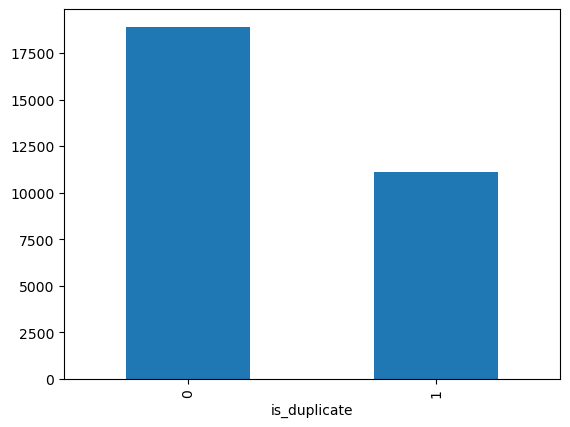

In [9]:
# Distrubution of duplicates and non-duplicates

print(new_df['is_duplicate'].value_counts())
print((new_df['is_duplicate'].value_counts()/new_df['is_duplicate'].count())*100)
new_df['is_duplicate'].value_counts().plot(kind = "bar")

In [10]:
# Repeated questions
qid = pd.Series(new_df['qid1'].tolist() + new_df['qid2'].tolist())
print("Number of unique questions", np.unique(qid).shape[0])
x = qid.value_counts() > 1
print("Number of questions getting repeated", x[x].shape[0])

Number of unique questions 59824
Number of questions getting repeated 160


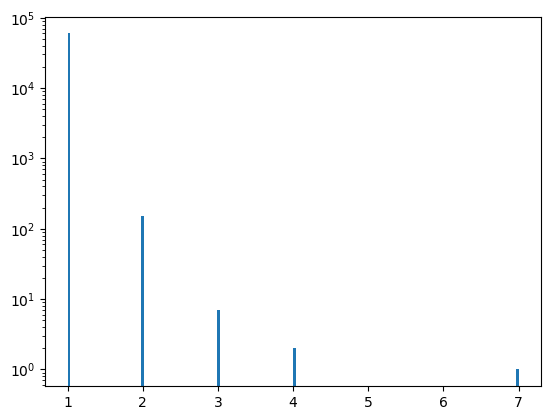

In [11]:
# Repeated question histogram
plt.hist(qid.value_counts().values, bins = 160)
plt.yscale('log')
plt.show()

In [12]:
# Feature Engineering

new_df['q1_len'] = new_df['question1'].str.len()
new_df['q2_len'] = new_df['question2'].str.len()

In [13]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len
120567,120567,238932,238933,How does the Boggart work?,What would the boggart of a boggart be?,0,26,39
324466,324466,636476,636477,What is difference between project manager and...,What are the differences between project manag...,0,63,76
398558,398558,778728,778729,What hotel in Jabalpur would be safe for unmar...,What hotel in Allahabad would be safe for unma...,0,124,125
339914,339914,666314,666315,What is stronger - Super Saiyan 4 or Super Sai...,How does Gohan turn into Super Saiyan 2?,0,54,40
185732,185732,366764,366765,How do I fill in Address Line 1 and Address Li...,How do I register desired web address?,0,51,38


In [14]:
new_df['q1_num_words'] = new_df['question1'].apply(lambda row : len(row.split(" ")))
new_df['q2_num_words'] = new_df['question2'].apply(lambda row : len(row.split(" ")))
new_df.head()                                                

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words
120567,120567,238932,238933,How does the Boggart work?,What would the boggart of a boggart be?,0,26,39,5,8
324466,324466,636476,636477,What is difference between project manager and...,What are the differences between project manag...,0,63,76,9,10
398558,398558,778728,778729,What hotel in Jabalpur would be safe for unmar...,What hotel in Allahabad would be safe for unma...,0,124,125,20,20
339914,339914,666314,666315,What is stronger - Super Saiyan 4 or Super Sai...,How does Gohan turn into Super Saiyan 2?,0,54,40,11,8
185732,185732,366764,366765,How do I fill in Address Line 1 and Address Li...,How do I register desired web address?,0,51,38,12,7


In [15]:
def common_words(row):
    w1 = set(map(lambda word : word.lower().strip(), row['question1'].split(" ")))
    w2 = set(map(lambda word : word.lower().strip(), row['question2'].split(" ")))
    return len(w1 & w2)

In [16]:
new_df['word_common'] = new_df.apply(common_words, axis = 1)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common
120567,120567,238932,238933,How does the Boggart work?,What would the boggart of a boggart be?,0,26,39,5,8,2
324466,324466,636476,636477,What is difference between project manager and...,What are the differences between project manag...,0,63,76,9,10,4
398558,398558,778728,778729,What hotel in Jabalpur would be safe for unmar...,What hotel in Allahabad would be safe for unma...,0,124,125,20,20,18
339914,339914,666314,666315,What is stronger - Super Saiyan 4 or Super Sai...,How does Gohan turn into Super Saiyan 2?,0,54,40,11,8,2
185732,185732,366764,366765,How do I fill in Address Line 1 and Address Li...,How do I register desired web address?,0,51,38,12,7,3


In [17]:
def total_words(row):
    w1 = set(map(lambda word : word.lower().strip(), row['question1'].split(" ")))
    w2 = set(map(lambda word : word.lower().strip(), row['question2'].split(" ")))
    return (len(w1) + len(w2))

In [18]:
new_df['word_total'] = new_df.apply(total_words, axis = 1)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total
120567,120567,238932,238933,How does the Boggart work?,What would the boggart of a boggart be?,0,26,39,5,8,2,12
324466,324466,636476,636477,What is difference between project manager and...,What are the differences between project manag...,0,63,76,9,10,4,19
398558,398558,778728,778729,What hotel in Jabalpur would be safe for unmar...,What hotel in Allahabad would be safe for unma...,0,124,125,20,20,18,38
339914,339914,666314,666315,What is stronger - Super Saiyan 4 or Super Sai...,How does Gohan turn into Super Saiyan 2?,0,54,40,11,8,2,17
185732,185732,366764,366765,How do I fill in Address Line 1 and Address Li...,How do I register desired web address?,0,51,38,12,7,3,17


In [19]:
new_df['word_share'] = round(new_df['word_common']/new_df['word_total'],2)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share
120567,120567,238932,238933,How does the Boggart work?,What would the boggart of a boggart be?,0,26,39,5,8,2,12,0.17
324466,324466,636476,636477,What is difference between project manager and...,What are the differences between project manag...,0,63,76,9,10,4,19,0.21
398558,398558,778728,778729,What hotel in Jabalpur would be safe for unmar...,What hotel in Allahabad would be safe for unma...,0,124,125,20,20,18,38,0.47
339914,339914,666314,666315,What is stronger - Super Saiyan 4 or Super Sai...,How does Gohan turn into Super Saiyan 2?,0,54,40,11,8,2,17,0.12
185732,185732,366764,366765,How do I fill in Address Line 1 and Address Li...,How do I register desired web address?,0,51,38,12,7,3,17,0.18


minimum characters 1
maximum charactes 345
average num of characters 59


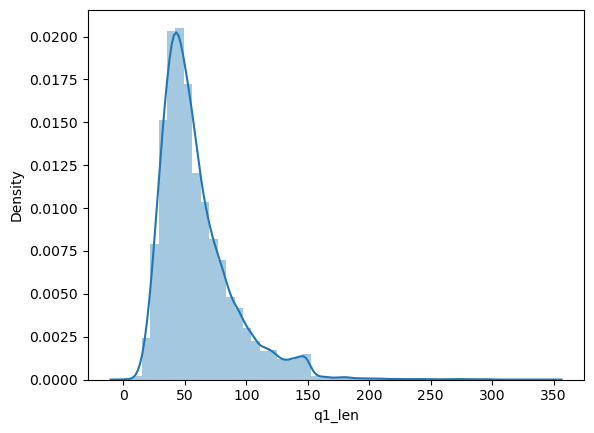

In [20]:
# Analysis of features
sns.distplot(new_df['q1_len'])
print("minimum characters", new_df['q1_len'].min())
print("maximum charactes", new_df['q1_len'].max())
print("average num of characters", int(new_df['q1_len'].mean()))

minimum characters 11
maximum characters 1151
average characters 60


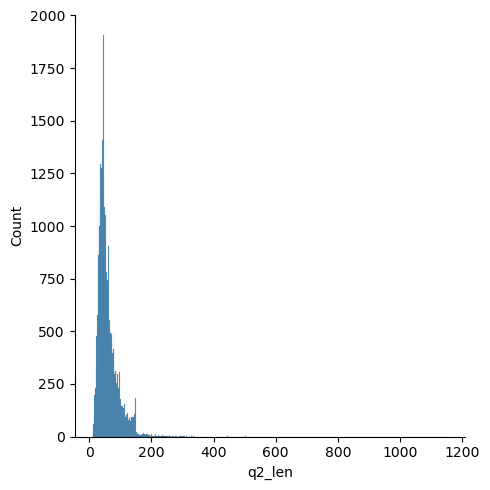

In [21]:
sns.displot(new_df['q2_len'])
print("minimum characters", new_df['q2_len'].min())
print("maximum characters", new_df['q2_len'].max())
print("average characters", int(new_df['q2_len'].mean()))

Minimum Words:  1
Maximum Words:  68
Average Words:  10


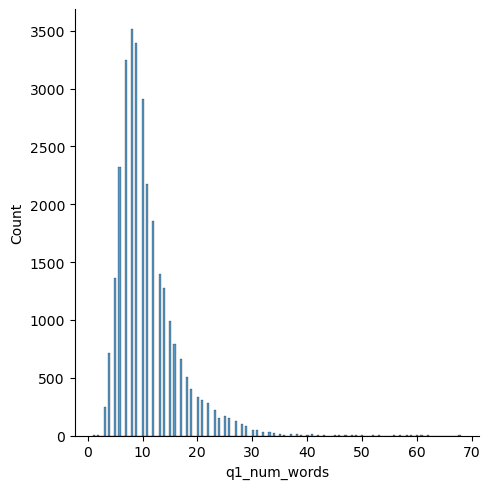

In [22]:
# analysis of words
sns.displot(new_df['q1_num_words'])
print("Minimum Words: ", new_df['q1_num_words'].min())
print("Maximum Words: ", new_df['q1_num_words'].max())
print("Average Words: ", int(new_df['q1_num_words'].mean()))

minimum words:  2
maximum words:  237
Average words:  11


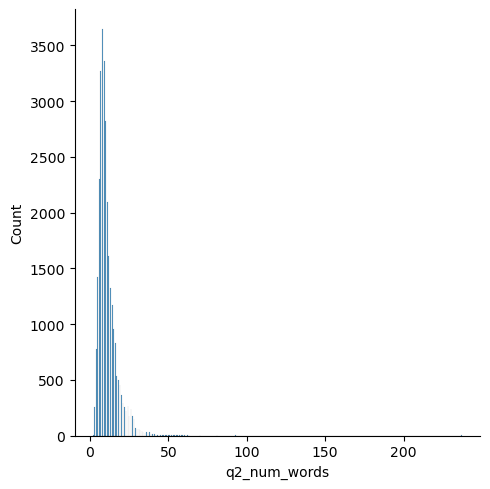

In [23]:
sns.displot(new_df['q2_num_words'])
print("minimum words: ", np.min(new_df['q2_num_words']))
print("maximum words: ", np.max(new_df['q2_num_words']))
print("Average words: ", int(np.mean(new_df['q2_num_words'])))

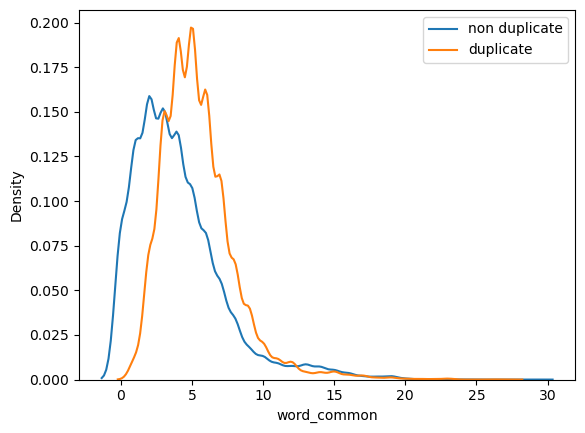

In [24]:
# Common words 
sns.kdeplot(new_df[new_df['is_duplicate'] == 0]['word_common'], label = 'non duplicate')
sns.kdeplot(new_df[new_df['is_duplicate'] == 1]['word_common'], label = 'duplicate')
plt.legend()
plt.show()

agar hamare question one and question me common word ka count 4 se jyada hain the uske duplicate hone ka probabality jyada hai

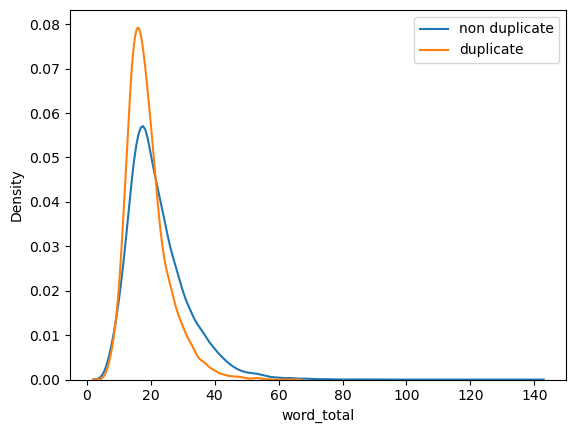

In [25]:
# total words
sns.kdeplot(new_df[new_df['is_duplicate'] == 0]['word_total'], label = 'non duplicate')
sns.kdeplot(new_df[new_df['is_duplicate'] == 1]['word_total'], label = 'duplicate')
plt.legend()
plt.show()

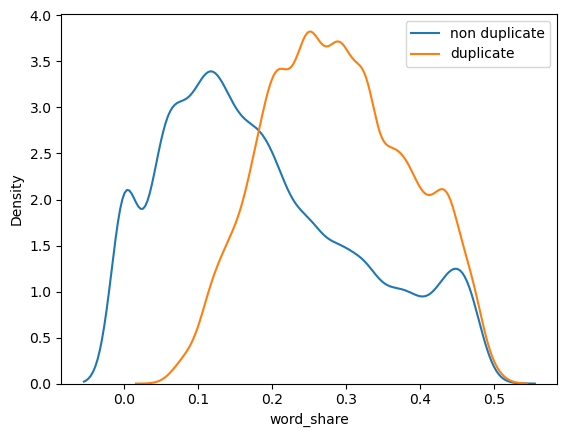

In [26]:
# word share
sns.kdeplot(new_df[new_df['is_duplicate'] == 0]['word_share'], label = 'non duplicate')
sns.kdeplot(new_df[new_df['is_duplicate'] == 1]['word_share'], label = 'duplicate')
plt.legend()
plt.show()

0.2 ke value agar word share hain toh non duplicate hone ka chance jyada hain and agar 0.2 ke baad hain toh duplicate hone ka chance jyada hain

In [27]:
ques_df = new_df[["question1","question2"]]
ques_df.head()

,question1,question2
120567,How does the Boggart work?,What would the boggart of a boggart be?
324466,What is difference between project manager and...,What are the differences between project manag...
398558,What hotel in Jabalpur would be safe for unmar...,What hotel in Allahabad would be safe for unma...
339914,What is stronger - Super Saiyan 4 or Super Sai...,How does Gohan turn into Super Saiyan 2?
185732,How do I fill in Address Line 1 and Address Li...,How do I register desired web address?


In [28]:
final_df = new_df.drop(columns = ["id","qid1","qid2","question1","question2"])
print(final_df.shape)
final_df.head()

(30000, 8)


,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share
120567,0,26,39,5,8,2,12,0.17
324466,0,63,76,9,10,4,19,0.21
398558,0,124,125,20,20,18,38,0.47
339914,0,54,40,11,8,2,17,0.12
185732,0,51,38,12,7,3,17,0.18


In [29]:
from sklearn.feature_extraction.text import CountVectorizer
# merge texts
questions = list(ques_df['question1']) + list(ques_df['question2'])
cv = CountVectorizer(max_features = 3000)
q1_arr, q2_arr = np.vsplit(cv.fit_transform(questions).toarray(), 2)

In [30]:
temp_df1 = pd.DataFrame(q1_arr, index = ques_df.index)
temp_df2 = pd.DataFrame(q2_arr, index = ques_df.index)
temp_df = pd.concat([temp_df1, temp_df2], axis = 1)
temp_df.shape

(30000, 6000)

In [31]:
final_df = pd.concat([final_df, temp_df], axis = 1)
print(final_df.shape)
final_df.head()

(30000, 6008)


,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share,0,1,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
120567,0,26,39,5,8,2,12,0.17,0,0,...,0,0,0,0,0,0,0,0,0,0
324466,0,63,76,9,10,4,19,0.21,0,0,...,0,0,0,0,0,0,0,0,0,0
398558,0,124,125,20,20,18,38,0.47,0,0,...,0,0,0,0,0,0,0,0,0,0
339914,0,54,40,11,8,2,17,0.12,0,0,...,0,0,0,0,0,0,0,0,0,0
185732,0,51,38,12,7,3,17,0.18,0,0,...,0,0,0,0,0,0,0,0,0,0


In [32]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(final_df.iloc[:,1:].values, final_df.iloc[:,0].values, test_size = 0.2, random_state = 42)

In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
accuracy_score(y_test, y_pred)

0.7691666666666667

In [35]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)
accuracy_score(y_test, y_pred)

0.7623333333333333